<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/ML-CPV-Documents/blob/main/RANDOMFOREST_DU_DO%C3%81N_MAU_SAC_RUOU_VANG_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ĐỌC DỮ LIỆU & KHÁM PHÁ DỮ LIỆU (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
import pandas as pd
# 1. Đọc dữ liệu "Wine_Quality_Data.csv"
df = pd.read_csv('Wine_Quality_Data.csv')

In [3]:
# 2. Xem cấu trúc dữ liệu ban đầu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


```
Cấu trúc của Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB
None
```

Dataset có tổng cộng 6,497 dòng và 13 cột. Trong đó có 11 đặc trưng hóa lý (features) như fixed_acidity, volatile_acidity, total_sulfur_dioxide, pH, alcohol,... và 1 cột chất lượng quality. Biến mục tiêu là color dạng chuỗi (red và white).

# Mã hóa biến mục tiêu (Label Encoding)

In [5]:
import numpy as np
df['color'] = np.where(df['color'] == 'white', 0, 1)

# BƯỚC 2: DATA PREPARATION

 tách dữ liệu thành ma trận đặc trưng $X$ (bỏ cột color) và vectơ mục tiêu $Y$ (chỉ giữ cột color). Sau đó chia dữ liệu theo tỉ lệ 80% Train và 20% Test.

ưu điểm cực kỳ lớn của Random Forest so với Logistic Regression hay Support Vector Machine (SVM) là thuật toán này dựa trên các Cây quyết định (Decision Trees) phân tách theo ngưỡng giá trị, nên nó không nhạy cảm với scale (quy mô) của dữ liệu. Vì vậy, bước chuẩn hóa dữ liệu (StandardScaler) là không cần thiết đối với Random Forest

In [6]:
# Tách đặc trưng và nhãn
X = df.drop('color', axis=1)
y = df['color']

In [8]:
from sklearn.model_selection import train_test_split
# Chia tập dữ liệu Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (5197, 12)
Kích thước tập Test: (1300, 12)


```
Kích thước tập Train: (5197, 12)
Kích thước tập Test: (1300, 12)
```

# BƯỚC 3: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH RANDOM FOREST

In [10]:
from sklearn.ensemble import RandomForestClassifier
# Khởi tạo mô hình Random Forest sử dụng n_estimators=100
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [11]:
# Huấn luyện mô hình trên tập Train
rf_model.fit(X_train, y_train)
print("Huấn luyên OK")

Huấn luyên OK


# BƯỚC 4: ĐÁNH GIÁ MÔ HÌNH (EVALUATION)

In [12]:
# Dự đoán nhãn trên tập kiểm thử
y_pred = rf_model.predict(X_test)

In [15]:
from sklearn.metrics import confusion_matrix
# Xuất kết quả đánh giá
print("CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

CONFUSION MATRIX
[[958   1]
 [  7 334]]


In [16]:
from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       959
           1       1.00      0.98      0.99       341

    accuracy                           0.99      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       0.99      0.99      0.99      1300



In [18]:
from sklearn.metrics import accuracy_score
# Điểm Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác tổng thể (Accuracy): {accuracy*100:.2f}%")

Độ chính xác tổng thể (Accuracy): 99.38%


# BƯỚC 5: FEATURE IMPORTANCE

In [19]:
# Lấy độ quan trọng của các biến
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

/tmp/ipykernel_1885/4197001455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis", legend=False)


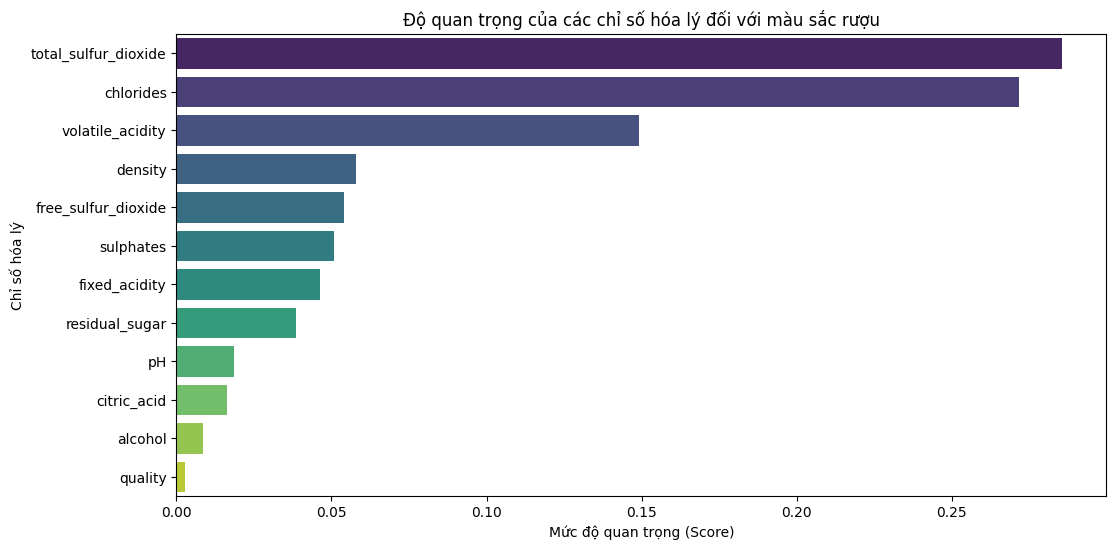

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
# Trực quan hóa bằng biểu đồ cột
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis", legend=False)
plt.title("Độ quan trọng của các chỉ số hóa lý đối với màu sắc rượu")
plt.xlabel("Mức độ quan trọng (Score)")
plt.ylabel("Chỉ số hóa lý")
plt.show()

# BƯỚC 6: TRIỂN KHAI DỰ ĐOÁN MẪU THỬ THỰC TẾ

In [22]:
# Thong tin 2 chai rượu mới
new_wines = np.array([
    [7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4, 5], # Chai số 1
    [6.3, 0.30, 0.34, 1.6, 0.049, 14.0, 132.0, 0.994, 3.30, 0.49, 9.5, 6]  # Chai số 2
])

In [24]:
# Tính xác suất thuộc về các lớp
probabilities = rf_model.predict_proba(new_wines)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
# Dự đoán nhãn cuối cùng
predictions = rf_model.predict(new_wines)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [26]:
print("KẾT QUẢ RANDOM FOREST")
for i, (prob, pred) in enumerate(zip(probabilities, predictions)):
    color_label = "RƯỢU TRẮNG (White)" if pred == 0 else "RƯỢU ĐỎ (Red)"
    print(f"Chai rượu số {i+1}:")
    print(f"  - Xác suất là rượu đỏ: {prob[1]*100:.2f}%")
    print(f"  - Xác suất là rượu trắng: {prob[0]*100:.2f}%")
    print(f"  => Dự đoán nhãn cuối cùng: {color_label}\n")

KẾT QUẢ RANDOM FOREST
Chai rượu số 1:
  - Xác suất là rượu đỏ: 100.00%
  - Xác suất là rượu trắng: 0.00%
  => Dự đoán nhãn cuối cùng: RƯỢU ĐỎ (Red)

Chai rượu số 2:
  - Xác suất là rượu đỏ: 0.00%
  - Xác suất là rượu trắng: 100.00%
  => Dự đoán nhãn cuối cùng: RƯỢU TRẮNG (White)

